<a href="https://colab.research.google.com/github/luisferojedat/claimai-policy-analyzer/blob/main/Actividad1_MLP_LFOT1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Requisitos del entorno

Este notebook requiere:
- Python 3
- `torch`
- `torchvision`
- `matplotlib`
- `pillow`
- `ipywidgets`

In [1]:
import sys
import subprocess

print("Python usado por este Jupyter:")
print(sys.executable)

subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "torch",
    "torchvision",
    "matplotlib",
    "pillow",
    "ipywidgets"
])

print("✓ Dependencias instaladas")

Python usado por este Jupyter:
/usr/bin/python3
✓ Dependencias instaladas


In [2]:
import torch
import torchvision
import matplotlib
import PIL
import ipywidgets

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("✓ Entorno Jupyter preparado correctamente")

PyTorch: 2.9.0+cpu
Torchvision: 0.24.0+cpu
✓ Entorno Jupyter preparado correctamente


In [3]:
import importlib.util
import sys

_CAN_PROCEED_WITH_MODEL_TRAINING = True
_IPYWIDGETS_AVAILABLE = True

required_packages = {
    "torch": "torch",
    "torchvision": "torchvision",
    "matplotlib": "matplotlib",
    "PIL": "pillow" # 'PIL' is the module name, 'pillow' is the package name
}

missing_critical_packages = []

# Check critical dependencies for model training and plotting
for module_name, package_name in required_packages.items():
    if importlib.util.find_spec(module_name) is None:
        missing_critical_packages.append(package_name)

if missing_critical_packages:
    print("Faltan dependencias CRÍTICAS para el entrenamiento del modelo:")
    for pkg in missing_critical_packages:
        print(f"- {pkg}")
    print("\nPor favor, instálelas para poder ejecutar el notebook completamente.")
    print("%pip install " + " ".join(missing_critical_packages))
    _CAN_PROCEED_WITH_MODEL_TRAINING = False
else:
    print("✓ Dependencias críticas para el modelo preparadas correctamente.")

# Check ipywidgets separately as it's for interactive demo
if importlib.util.find_spec("ipywidgets") is None:
    print("\n⚠️ Aviso: 'ipywidgets' no está instalado. La demo interactiva no funcionará.")
    print("Para habilitar la demo, instale: %pip install ipywidgets")
    _IPYWIDGETS_AVAILABLE = False
else:
    print("✓ 'ipywidgets' disponible para la demo interactiva.")


if not _CAN_PROCEED_WITH_MODEL_TRAINING:
    print("\n🛑 La ejecución de las celdas relacionadas con el modelo se ha detenido.")


✓ Dependencias críticas para el modelo preparadas correctamente.
✓ 'ipywidgets' disponible para la demo interactiva.


<!-- Esta celda está comentada para evitar la instalación automática en cada ejecución de 'Run All'. -->
<!-- Descomente y ejecute si faltan dependencias según el diagnóstico anterior. -->

In [4]:
# Ejecutar solo si faltan dependencias:
# %pip install torch torchvision matplotlib pillow ipywidgets

# FashionMNIST · MLP

### Actividad 1 · Clasificación inteligente de prendas mediante Perceptrón Multicapa

Diseño, entrenamiento y evaluación de una red MLP para clasificar las
10 categorías de FashionMNIST, utilizando validación independiente y
análisis posterior de las predicciones.

**Dataset** FashionMNIST  ·  **Modelo** MLP  ·  **Clases** 10  ·  **Entrada** 28×28

In [5]:
import copy

# Conditionally import core libraries required for model training and evaluation
if _CAN_PROCEED_WITH_MODEL_TRAINING:
    import torch
    from torch import nn
    from torch import optim #las funciones de optimizacion (gradient descent)
    from torch.optim.lr_scheduler import StepLR #learning rate decay
    import torch.nn.functional as F #convencion
    from torchvision import datasets, transforms

    # matplotlib para pintar graficas
    import matplotlib.pyplot as plt

    # IPython.display para HTML y display (siempre se necesita para los dashboards)
    from IPython.display import display, HTML

    %matplotlib inline

    # Conditionally import ipywidgets for interactive elements
    if _IPYWIDGETS_AVAILABLE:
        import ipywidgets as widgets
        from IPython.display import clear_output # clear_output es necesaria para ipywidgets
    else:
        # Placeholder/mock for ipywidgets if not available, to prevent NameError later
        class MockWidget:
            def __init__(self, *args, **kwargs): pass
            def observe(self, *args, **kwargs): pass
        widgets = type('module', (object,), {'Button': MockWidget, 'FileUpload': MockWidget, 'Output': MockWidget})()
        clear_output = lambda wait: None # Mock clear_output

else:
    print("No se cargaron las librerías de PyTorch y otras dependencias críticas.")
    print("El entrenamiento y la evaluación del modelo no podrán proceder.")
    # Define mocks or None for critical objects to prevent NameError in subsequent cells
    torch = None
    nn = None
    optim = None
    StepLR = None
    F = None
    datasets = None
    transforms = None
    plt = None
    display = lambda x: None
    HTML = lambda x: None
    # Define mocks for ipywidgets if _IPYWIDGETS_AVAILABLE is False, or if _CAN_PROCEED_WITH_MODEL_TRAINING is False
    class MockWidget:
        def __init__(self, *args, **kwargs): pass
        def observe(self, *args, **kwargs): pass
    widgets = type('module', (object,), {'Button': MockWidget, 'FileUpload': MockWidget, 'Output': MockWidget})()
    clear_output = lambda wait: None # Mock clear_output



In [6]:
# Paleta de colores estilo Apple para una estética minimalista y limpia
APPLE_BLUE = '#007AFF'
APPLE_GREEN = '#34C759'
APPLE_RED = '#FF3B30'
APPLE_GRAY = '#8E8E93'
APPLE_LIGHT = '#F5F5F7'


## 01 · Dataset

FashionMNIST contiene imágenes de prendas de 28×28 píxeles en escala de
gris. Los datos se separan en entrenamiento, validación y test para
distinguir aprendizaje, selección del modelo y evaluación final.

In [7]:
# usamos la GPU si esta disponible
if _CAN_PROCEED_WITH_MODEL_TRAINING and torch is not None:
  if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Dispositivo usado: GPU con CUDA")
  else:
    device = torch.device("cpu")
    print("Dispositivo usado: CPU")
else:
  device = "cpu" # Default to CPU if torch not available, though model won't run
  print("No se pudo determinar el dispositivo (Torch no disponible).")


Dispositivo usado: CPU


In [8]:
# Definir una transformación para convertir la imagen a un tensor
transform = transforms.Compose([
    transforms.ToTensor(), # hay que convertir a tensor los datos
    transforms.Normalize((0.2860,), (0.3530,)) # normalizacion del dataset
])

# Descargar el dataset FashionMNIST de articulos de ropa (entrenamiento completo y test)
dataset_full_train = datasets.FashionMNIST('data', train=True, download=True, transform=transform)
dataset_test = datasets.FashionMNIST('data', train=False, download=True, transform=transform)

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 260kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.05MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.0MB/s]


In [9]:
# la media y desviacion del dataset son los valores por los que se normaliza
# es buena idea normalizar el dataset para ayudar a que converja mas rapido
print("media: ", dataset_full_train.data.float().mean()/255)
print("desviacion: ", dataset_full_train.data.float().std()/255)

media:  tensor(0.2860)
desviacion:  tensor(0.3530)


In [10]:
# Dividir el dataset de entrenamiento completo en conjuntos de entrenamiento y validación
split_generator = torch.Generator().manual_seed(42)

dataset_train, dataset_validation = torch.utils.data.random_split(
    dataset_full_train,
    [54000, 6000],
    generator=split_generator
)

In [11]:
# tamaño del mini-batch
batch_size = 64

# generamos los dataloaders que se usaran para leer
# las imagenes el entrenamiento, validación y test
train_loader = torch.utils.data.DataLoader(
    dataset_train,
    batch_size=batch_size,
    shuffle=True
)

validation_loader = torch.utils.data.DataLoader(
    dataset_validation,
    batch_size=batch_size,
    shuffle=False
)

test_loader = torch.utils.data.DataLoader(
    dataset_test,
    batch_size=batch_size,
    shuffle=False
)

# categoria de ropa que corresponde a cada numero
desc = [
    'Camiseta/top',
    'Pantalón',
    'Jersey',
    'Vestido',
    'Abrigo',
    'Sandalia',
    'Camisa',
    'Zapatilla',
    'Bolso',
    'Bota'
]

### Resumen del Dataset

<div style="display: flex; gap: 20px; flex-wrap: wrap;">
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">TRAIN</h4>
        <p style="font-size: 1.8em; font-weight: bold; margin: 0; color: #333;">54.000</p>
    </div>
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">VALIDATION</h4>
        <p style="font-size: 1.8em; font-weight: bold; margin: 0; color: #333;">6.000</p>
    </div>
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">TEST</h4>
        <p style="font-size: 1.8em; font-weight: bold; margin: 0; color: #333;">10.000</p>
    </div>
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">CLASES</h4>
        <p style="font-size: 1.8em; font-weight: bold; margin: 0; color: #333;">10</p>
    </div>
</div>

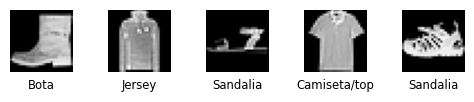

In [12]:
figure = plt.figure(figsize=(5, 1))

# configurar tamaño de texto para las graficas
plt.rc('font', size=7)

for i in range(0,5):
  figure.add_subplot(1, 5, i+1)
  img, label = dataset_train[i]

  # img tiene dimensiones [1,28,28], squeeze() destruye las dimensiones de tamaño 1
  plt.imshow(img.squeeze(), cmap='Greys_r')
  plt.axis('off')
  plt.title(desc[label], y=-0.4)

plt.tight_layout()
plt.show()

## 02 · Modelo

Una red Perceptrón Multicapa transforma los 784 valores de cada imagen
mediante tres capas ocultas hasta obtener 10 valores de salida (logits),
uno por categoría. Durante la inferencia, estos logits se convierten en
probabilidades mediante Softmax.

In [13]:
input_size = 784
output_size = 10
hidden_sizes = [512, 256, 128]

In [14]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super(MLP, self).__init__()
        self.layers = nn.ModuleList()

        # Input layer to first hidden layer
        self.layers.append(nn.Linear(input_size, hidden_sizes[0]))

        # Subsequent hidden layers
        for i in range(len(hidden_sizes) - 1):
            self.layers.append(nn.Linear(hidden_sizes[i], hidden_sizes[i+1]))

        # Last hidden layer to output layer
        self.layers.append(nn.Linear(hidden_sizes[-1], output_size))

        self.activation = nn.ReLU()
        # La salida del modelo son logits. CrossEntropyLoss trabaja directamente con estos valores,
        # (sin requerir Softmax explícito), ya que combina internamente LogSoftmax y la pérdida de log-verosimilitud negativa.

    def forward(self, x):
        # Flatten the image input
        x = x.view(x.size(0), -1)

        for i, layer in enumerate(self.layers):
            x = layer(x)
            # Se aplica ReLU a todas las capas excepto a la última (capa de salida),
            # que ahora producirá logits directamente.
            if i < len(self.layers) - 1:
                x = self.activation(x)
        return x

In [15]:
torch.manual_seed(42)

model = MLP(input_size, hidden_sizes, output_size).to(device)

print(model)

total_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"\nParámetros entrenables: {total_params:,}")

MLP(
  (layers): ModuleList(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): Linear(in_features=512, out_features=256, bias=True)
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
  (activation): ReLU()
)

Parámetros entrenables: 567,434


In [16]:
from IPython.display import display, HTML

if 'total_params' not in globals():
    print("Error: 'total_params' no está definida. Por favor, asegúrese de ejecutar la celda donde se define el modelo y se calculan los parámetros (celda 'ffad3662').")
else:
    html_panel = f"""
    <div style="display: flex; gap: 20px; flex-wrap: wrap;">
        <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
            <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">ARQUITECTURA</h4>
            <p style="font-size: 1.2em; font-weight: bold; margin: 0; color: #333;">784 → 512 → 256 → 128 → 10</p>
        </div>
        <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
            <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">CAPAS OCULTAS</h4>
            <p style="font-size: 1.8em; font-weight: bold; margin: 0; color: #333;">3</p>
        </div>
        <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
            <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">ACTIVACIÓN</h4>
            <p style="font-size: 1.8em; font-weight: bold; margin: 0; color: #333;">ReLU</p>
        </div>
        <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
            <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">SALIDA</h4>
            <p style="font-size: 1.8em; font-weight: bold; margin: 0; color: #333;">10 logits</p>
        </div>
        <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
            <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">PARÁMETROS</h4>
            <p style="font-size: 1.8em; font-weight: bold; margin: 0; color: #333;">{total_params:,}</p>
        </div>
    </div>
    """
    display(HTML(html_panel))

Muestra de predicciones iniciales (antes de entrenamiento):


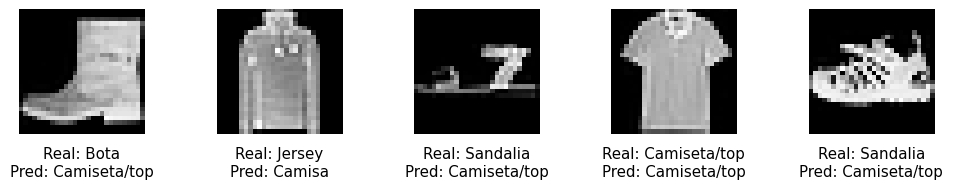

In [17]:
print('Muestra de predicciones iniciales (antes de entrenamiento):')

figure = plt.figure(figsize=(10, 2))
plt.rc('font', size=9)

model.eval() # Set the model to evaluation mode

with torch.no_grad(): # Disable gradient calculations
    for i in range(5):
        figure.add_subplot(1, 5, i + 1)
        img, label = dataset_train[i]

        # Prepare input for the model: add batch dimension, flatten, move to device
        input_img = img.view(1, 28 * 28).to(device)

        # Get model predictions
        output = model(input_img)
        predicted_class = torch.argmax(output).item()

        plt.imshow(img.squeeze(), cmap='Greys_r')
        plt.axis('off')
        plt.title(f"Real: {desc[label]}\nPred: {desc[predicted_class]}", y=-0.4)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

In [ ]:
from torchvision import datasets
import os
import zipfile

# Dataset original de prueba FashionMNIST
demo_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True
)

class_names = [
    "camiseta_top",
    "pantalon",
    "jersey",
    "vestido",
    "abrigo",
    "sandalia",
    "camisa",
    "zapatilla",
    "bolso",
    "botin"
]

os.makedirs("imagenes_demo_28x28", exist_ok=True)

saved_classes = set()

for i in range(len(demo_dataset)):

    image, label = demo_dataset[i]

    if label not in saved_classes:

        filename = (
            f"imagenes_demo_28x28/"
            f"{label}_{class_names[label]}_28x28.png"
        )

        image.save(filename)

        saved_classes.add(label)

    if len(saved_classes) == 10:
        break

zip_name = "FashionMNIST_10_imagenes_28x28.zip"

with zipfile.ZipFile(zip_name, "w") as zipf:

    for filename in sorted(
        os.listdir("imagenes_demo_28x28")
    ):

        full_path = os.path.join(
            "imagenes_demo_28x28",
            filename
        )

        zipf.write(
            full_path,
            arcname=filename
        )

print("ZIP creado:", zip_name)

try:
    from google.colab import files
    files.download(zip_name)
    print("Descarga iniciada en Google Colab.")
except ImportError:
    print("El módulo 'google.colab' no está disponible. El archivo ZIP se ha creado localmente y está disponible en el entorno de Colab, pero no se pudo iniciar la descarga automática.")


## 03 · Entrenamiento

Los pesos se optimizan mediante SGD. Tras cada epoch, el conjunto de
validación mide la capacidad de generalización y permite conservar el mejor
estado de la red.

In [18]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    for batch_idx, (data, target) in enumerate(loader):
        data = data.to(device)
        target = target.to(device)
        optimizer.zero_grad()
        data = data.view(data.shape[0], 28 * 28) # Flatten image
        output = model(data)
        # Se usa CrossEntropyLoss, que espera logits del modelo
        # y etiquetas enteras (no one-hot encoded).
        loss = F.cross_entropy(
            output,
            target
        )
        loss.backward()
        optimizer.step()
        loss_training.append(loss.item())

In [19]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total_loss = 0.0
    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            target = target.to(device)
            data = data.view(data.shape[0], 28 * 28) # Flatten image
            output = model(data)
            # Se usa CrossEntropyLoss para calcular la pérdida.
            # La función espera logits y etiquetas enteras.
            total_loss += F.cross_entropy(
                output,
                target,
                reduction='sum'
            ).item()
            pred = output.argmax(dim=1) # Predicción: la clase correspondiente al logit con el valor más alto
            correct += (pred == target).sum().item()

    # La CrossEntropyLoss devuelve una pérdida media por muestra (si reduction='mean'),
    # o una suma de pérdidas si reduction='sum').
    # Si es 'sum', se divide por el número total de muestras para obtener la media.
    total_loss /= len(loader.dataset)
    accuracy = 100.0 * correct / len(loader.dataset)
    errors = len(loader.dataset) - correct
    return total_loss, accuracy, errors

In [20]:
# Evaluación inicial del modelo sin entrenar
initial_val_loss, initial_val_accuracy, initial_val_errors = evaluate(model, validation_loader)

html_panel_initial_eval = f"""
<div style="display: flex; gap: 20px; flex-wrap: wrap;">
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">VALIDACIÓN INICIAL</h4>
        <p style="font-size: 1.2em; font-weight: bold; margin: 0; color: #333;">Accuracy: {initial_val_accuracy:.2f} %</p>
        <p style="font-size: 1.2em; font-weight: bold; margin: 0; color: #333;">Loss: {initial_val_loss:.4f}</p>
        <p style="font-size: 1.2em; font-weight: bold; margin: 0; color: #333;">Errores: {initial_val_errors:,}</p>
    </div>
</div>
"""
display(HTML(html_panel_initial_eval))

In [21]:
# Reinicialización definitiva del modelo y preparación para el entrenamiento
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Re-crear el modelo para asegurar el mismo estado inicial antes del entrenamiento
model = MLP(input_size, hidden_sizes, output_size).to(device)

# Listas para guardar el historial de métricas
loss_training = []
train_loss_history = []
validation_loss_history = []
train_accuracy_history = []
validation_accuracy_history = []
lr_history = []

# Variables para guardar el mejor modelo
best_validation_accuracy = -1.0
best_validation_loss = None
best_train_accuracy = None
best_train_loss = None
best_epoch = 0
best_model_state = None

# Hiperparámetros
lr = 0.5
gamma = 0.9
epochs = 20

optimizer = optim.SGD(
    model.parameters(),
    lr=lr
)

scheduler = StepLR(
    optimizer,
    step_size=1,
    gamma=gamma
)

print("Comenzando el entrenamiento...")
for epoch in range(1, epochs + 1):
    current_lr = optimizer.param_groups[0]['lr']
    lr_history.append(current_lr)

    train_one_epoch(model, train_loader, optimizer)

    train_loss, train_accuracy, _ = evaluate(model, train_loader)
    validation_loss, validation_accuracy, _ = evaluate(model, validation_loader)

    train_loss_history.append(train_loss)
    validation_loss_history.append(validation_loss)
    train_accuracy_history.append(train_accuracy)
    validation_accuracy_history.append(validation_accuracy)

    # Guardar el mejor modelo si la precisión de validación mejora
    if validation_accuracy > best_validation_accuracy:
        best_validation_accuracy = validation_accuracy
        best_validation_loss = validation_loss
        best_train_accuracy = train_accuracy
        best_train_loss = train_loss
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())

    scheduler.step()

    print(f"Epoch {epoch:02d}/{epochs} · Train {train_accuracy:.2f}% · Validation {validation_accuracy:.2f}% · Val Loss {validation_loss:.4f}")

assert best_model_state is not None, "No se encontró el mejor estado del modelo."
model.load_state_dict(best_model_state)

print("Entrenamiento completado.")

Comenzando el entrenamiento...
Epoch 01/20 · Train 84.90% · Validation 83.82% · Val Loss 0.4958
Epoch 02/20 · Train 87.18% · Validation 86.28% · Val Loss 0.3909
Epoch 03/20 · Train 88.72% · Validation 86.93% · Val Loss 0.3677
Epoch 04/20 · Train 89.63% · Validation 87.15% · Val Loss 0.3613
Epoch 05/20 · Train 90.80% · Validation 88.48% · Val Loss 0.3323
Epoch 06/20 · Train 91.09% · Validation 88.53% · Val Loss 0.3142
Epoch 07/20 · Train 92.10% · Validation 88.57% · Val Loss 0.3275
Epoch 08/20 · Train 92.24% · Validation 88.50% · Val Loss 0.3360
Epoch 09/20 · Train 92.90% · Validation 88.88% · Val Loss 0.3307
Epoch 10/20 · Train 93.97% · Validation 89.15% · Val Loss 0.3256
Epoch 11/20 · Train 94.72% · Validation 89.48% · Val Loss 0.3238
Epoch 12/20 · Train 94.70% · Validation 89.37% · Val Loss 0.3509
Epoch 13/20 · Train 95.34% · Validation 89.62% · Val Loss 0.3459
Epoch 14/20 · Train 95.64% · Validation 89.30% · Val Loss 0.3560
Epoch 15/20 · Train 96.08% · Validation 89.35% · Val Loss 0

## 04 · Validación

El conjunto de validación selecciona el estado del modelo que mejor
generaliza sin utilizar todavía los datos reservados para test.

In [22]:
# Verificación de los históricos
assert len(train_loss_history) == epochs
assert len(validation_loss_history) == epochs
assert len(train_accuracy_history) == epochs
assert len(validation_accuracy_history) == epochs
assert len(lr_history) == epochs

print("Históricos verificados correctamente.")

Históricos verificados correctamente.


In [23]:
generalization_gap = best_train_accuracy - best_validation_accuracy

html_panel_dashboard = f"""
<div style="display: flex; gap: 20px; flex-wrap: wrap;">
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">BEST VALIDATION</h4>
        <p style="font-size: 1.8em; font-weight: bold; margin: 0; color: #333;">{best_validation_accuracy:.2f} %</p>
    </div>
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">BEST EPOCH</h4>
        <p style="font-size: 1.8em; font-weight: bold; margin: 0; color: #333;">{best_epoch} / {epochs}</p>
    </div>
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">TRAIN AT BEST</h4>
        <p style="font-size: 1.8em; font-weight: bold; margin: 0; color: #333;">{best_train_accuracy:.2f} %</p>
    </div>
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">GENERALIZATION GAP</h4>
        <p style="font-size: 1.8em; font-weight: bold; margin: 0; color: #333;">{generalization_gap:.2f} pp</p>
    </div>
</div>
"""
display(HTML(html_panel_dashboard))

# Nivel de rúbrica
if best_validation_accuracy > 89:
    print("PRECISIÓN · SOBRESALIENTE\nValidation Accuracy > 89 %")
elif best_validation_accuracy > 85:
    print("PRECISIÓN · ACEPTABLE")
else:
    print("PRECISIÓN · MEJORABLE")

PRECISIÓN · SOBRESALIENTE
Validation Accuracy > 89 %


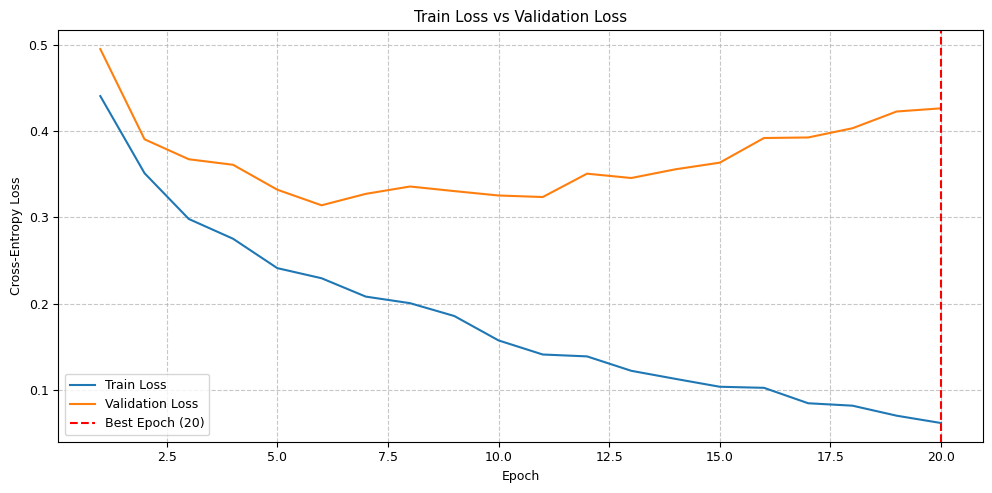

In [24]:
# Gráfica 1: Train Loss vs Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_loss_history, label='Train Loss')
plt.plot(range(1, epochs + 1), validation_loss_history, label='Validation Loss')
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Epoch ({best_epoch})')
plt.title('Train Loss vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

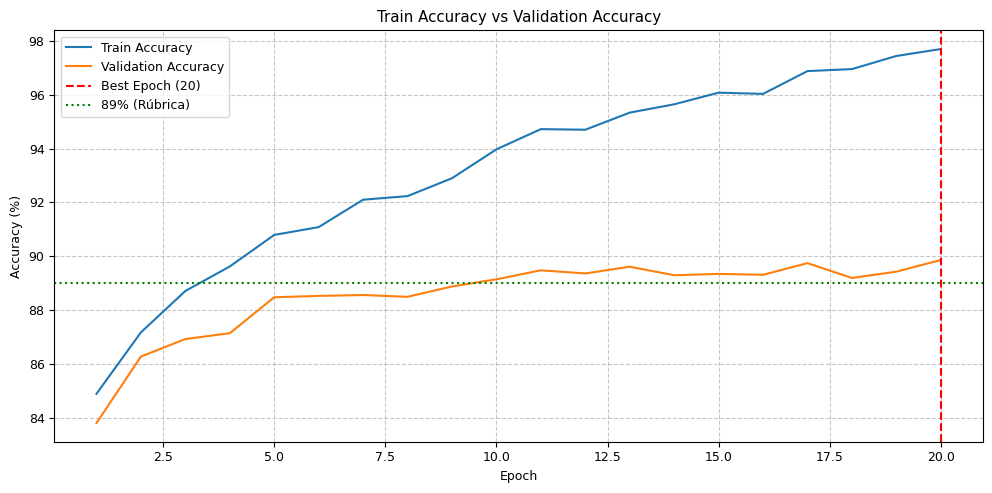

In [25]:
# Gráfica 2: Train Accuracy vs Validation Accuracy
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_accuracy_history, label='Train Accuracy')
plt.plot(range(1, epochs + 1), validation_accuracy_history, label='Validation Accuracy')
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Epoch ({best_epoch})')
plt.axhline(y=89, color='g', linestyle=':', label='89% (Rúbrica)')
plt.title('Train Accuracy vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 05 · Test final

El conjunto de test se mantuvo completamente independiente durante el entrenamiento y la selección del modelo. Una vez seleccionado el mejor estado mediante validación, se utiliza para la evaluación final y el análisis posterior de las predicciones.

In [26]:
# Evaluar el modelo final en el conjunto de test
final_test_loss, final_test_accuracy, final_test_errors = evaluate(
    model,
    test_loader
)

html_panel_final_eval = f"""
<div style="display: flex; gap: 20px; flex-wrap: wrap;">
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">TEST ACCURACY</h4>
        <p style="font-size: 1.8em; font-weight: bold; margin: 0; color: #333;">{final_test_accuracy:.2f} %</p>
    </div>
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">TEST LOSS</h4>
        <p style="font-size: 1.8em; font-weight: bold; margin: 0; color: #333;">{final_test_loss:.4f}</p>
    </div>
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">ERRORES</h4>
        <p style="font-size: 1.8em; font-weight: bold; margin: 0; color: #333;">{final_test_errors:,}</p>
    </div>
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 180px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">BEST VALIDATION</h4>
        <p style="font-size: 1.8em; font-weight: bold; margin: 0; color: #333;">{best_validation_accuracy:.2f} %</p>
    </div>
</div>
"""
display(HTML(html_panel_final_eval))

Muestra de predicciones en el conjunto de test:


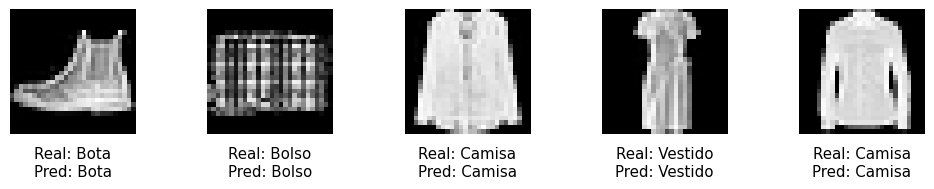

In [27]:
print('Muestra de predicciones en el conjunto de test:')

figure = plt.figure(figsize=(10, 2))
plt.rc('font', size=9)

model.eval()

with torch.no_grad():
    # Para asegurar la reproducibilidad, tomamos muestras específicas del test set
    # En lugar de usar random_split, podemos iterar el test_loader o acceder a dataset_test
    # Aquí accedemos directamente al dataset_test para 5 imágenes consecutivas y reproducibles
    torch.manual_seed(42) # para reproducibilidad de las muestras
    sample_indices = torch.randint(0, len(dataset_test), (5,)).tolist()

    for i, idx in enumerate(sample_indices):
        figure.add_subplot(1, 5, i + 1)
        img, label = dataset_test[idx]

        input_img = img.view(1, 28 * 28).to(device)
        output = model(input_img)
        predicted_class = torch.argmax(output).item()

        plt.imshow(img.squeeze(), cmap='Greys_r')
        plt.axis('off')
        plt.title(f"Real: {desc[label]}\nPred: {desc[predicted_class]}", y=-0.4)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

In [28]:
all_targets = []
all_predictions = []
all_confidences = [] # Almacenará las probabilidades Top-1 (confianza)

model.eval()

with torch.no_grad():

    for data, target in test_loader:

        data = data.to(device)
        target = target.to(device)

        output = model(
            data.view(data.shape[0], 28 * 28)
        )

        # Aplicar Softmax para obtener las probabilidades de los logits
        probabilities = torch.softmax(output, dim=1)

        pred = probabilities.argmax(dim=1) # Las predicciones se basan en la probabilidad más alta
        confidence = probabilities.max(dim=1).values # La confianza es la probabilidad del Top-1

        all_targets.append(target.cpu())
        all_predictions.append(pred.cpu())
        all_confidences.append(confidence.cpu())

all_targets = torch.cat(all_targets)
all_predictions = torch.cat(all_predictions)
all_confidences = torch.cat(all_confidences)

all_correct = (
    all_predictions == all_targets
)

print(
    f"Datos de test preparados: "
    f"{len(all_targets):,} muestras."
)

Datos de test preparados: 10,000 muestras.


## 06 · Model Intelligence

Más allá de la precisión global, analizamos dónde acierta el modelo,
dónde falla y cuándo una predicción presenta mayor incertidumbre.

### 6.1 Precisión por clase

In [29]:
class_correct = torch.zeros(output_size, dtype=torch.int64)
class_total = torch.zeros(output_size, dtype=torch.int64)

model.eval()
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data.view(data.shape[0], 28 * 28))
        pred = output.argmax(dim=1)

        # Mover a CPU antes de usar como índice
        target_cpu = target.cpu()
        pred_cpu = pred.cpu()

        for i in range(output_size):
            class_total[i] += (target_cpu == i).sum().item()
            class_correct[i] += ((pred_cpu == i) & (target_cpu == i)).sum().item()

class_accuracy = 100 * class_correct.float() / class_total.float()

print("Precisión por clase en el conjunto de test:")
print("\n| Clase       | Correctos | Total   | Accuracy |")
print("|:------------|:----------|:--------|:---------|")
for i in range(output_size):
    print(f"| {desc[i]:<11} | {class_correct[i].item():<9} | {class_total[i].item():<7} | {class_accuracy[i].item():<8.2f}% |")

best_class_idx = torch.argmax(class_accuracy).item()
worst_class_idx = torch.argmin(class_accuracy).item()

html_panel_class_accuracy = f"""
<div style="display: flex; gap: 20px; flex-wrap: wrap;">
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 220px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">MEJOR RECONOCIDA</h4>
        <p style="font-size: 1.2em; font-weight: bold; margin: 0; color: #333;">{desc[best_class_idx]} ({class_accuracy[best_class_idx]:.2f} %)</p>
    </div>
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 220px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">MAYOR DIFICULTAD</h4>
        <p style="font-size: 1.2em; font-weight: bold; margin: 0; color: #333;">{desc[worst_class_idx]} ({class_accuracy[worst_class_idx]:.2f} %)</p>
    </div>
</div>
"""
display(HTML(html_panel_class_accuracy))

Precisión por clase en el conjunto de test:

| Clase       | Correctos | Total   | Accuracy |
|:------------|:----------|:--------|:---------|
| Camiseta/top | 876       | 1000    | 87.60   % |
| Pantalón    | 975       | 1000    | 97.50   % |
| Jersey      | 803       | 1000    | 80.30   % |
| Vestido     | 908       | 1000    | 90.80   % |
| Abrigo      | 846       | 1000    | 84.60   % |
| Sandalia    | 962       | 1000    | 96.20   % |
| Camisa      | 712       | 1000    | 71.20   % |
| Zapatilla   | 952       | 1000    | 95.20   % |
| Bolso       | 976       | 1000    | 97.60   % |
| Bota        | 972       | 1000    | 97.20   % |


### 6.2 Matriz de confusión

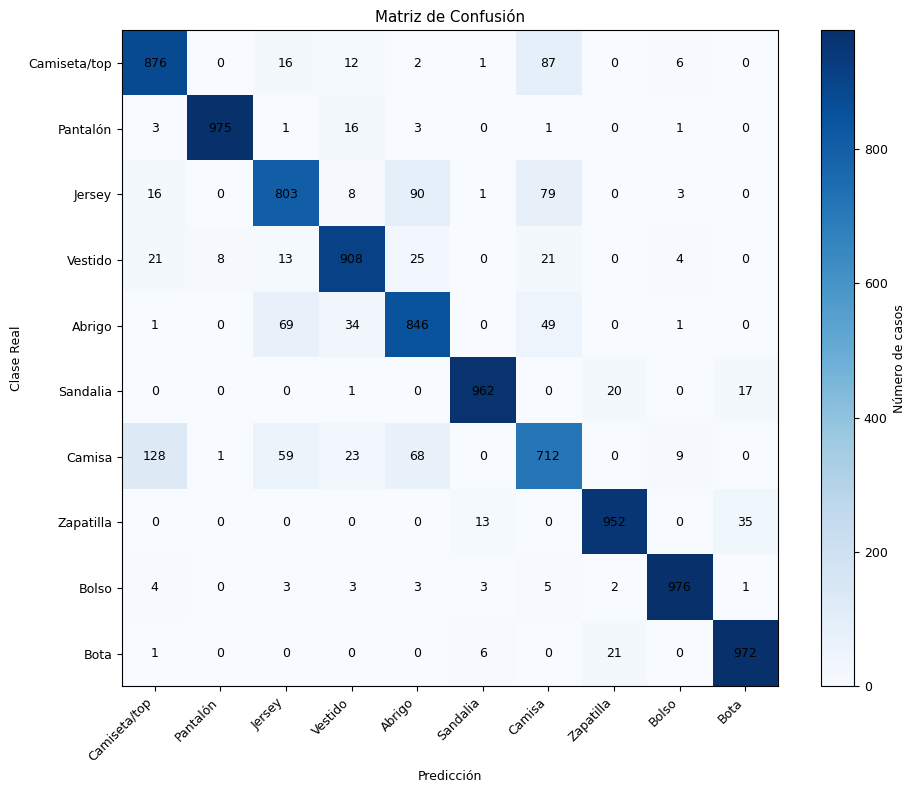

In [30]:
confusion = torch.zeros(output_size, output_size, dtype=torch.int64)

model.eval()
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data.view(data.shape[0], 28 * 28))
        pred = output.argmax(dim=1)

        # Mover a CPU antes de usar como índice
        target_cpu = target.cpu()
        pred_cpu = pred.cpu()

        for t, p in zip(target_cpu.view(-1), pred_cpu.view(-1)):
            confusion[t.long(), p.long()] += 1

plt.figure(figsize=(10, 8))
plt.imshow(confusion, cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Clase Real')
plt.xticks(range(output_size), desc, rotation=45, ha='right')
plt.yticks(range(output_size), desc)
plt.colorbar(label='Número de casos')

# Añadir valores numéricos a la matriz
for i in range(output_size):
    for j in range(output_size):
        plt.text(j, i, confusion[i, j].item(), ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

In [31]:
confusion_copy = confusion.clone()
# Poner la diagonal a cero para encontrar las confusiones
for i in range(output_size):
    confusion_copy[i, i] = 0

# Obtener las 3 confusiones más frecuentes
# Flatten the matrix to find top values and their original indices
flat_confusion = confusion_copy.view(-1)
top_k_values, top_k_indices = torch.topk(flat_confusion, 3)

print("Top 3 confusiones más frecuentes:")
for i in range(3):
    value = top_k_values[i].item()
    idx = top_k_indices[i].item()
    real_class = idx // output_size
    predicted_class = idx % output_size
    print(f"{i+1}. {desc[real_class]} → {desc[predicted_class]}: {value} casos")

Top 3 confusiones más frecuentes:
1. Camisa → Camiseta/top: 128 casos
2. Jersey → Abrigo: 90 casos
3. Camiseta/top → Camisa: 87 casos


### 6.3 Prediction Confidence

In [32]:
def confidence_level(confidence):
    if confidence >= 0.80:
        return "Alta"
    elif confidence >= 0.60:
        return "Media"
    else:
        return "Baja · revisar"

print('Muestra de predicciones con niveles de confianza:')

model.eval()
with torch.no_grad():
    torch.manual_seed(43) # Otra semilla para reproducibilidad de esta sección
    sample_indices = torch.randint(0, len(dataset_test), (5,)).tolist()

    for idx in sample_indices:
        img, label = dataset_test[idx]
        input_img = img.view(1, 28 * 28).to(device)
        output = model(input_img)
        # Se aplica Softmax explícitamente para obtener probabilidades
        # después de que el modelo produce logits.
        probabilities = torch.softmax(output, dim=1)

        # Get top 2 predictions and their probabilities
        top_k_probs, top_k_indices = torch.topk(probabilities, k=2, dim=1)

        top1_prob = top_k_probs[0, 0].item()
        top1_pred = top_k_indices[0, 0].item()

        top2_prob = top_k_probs[0, 1].item()
        top2_pred = top_k_indices[0, 1].item()

        print(f"\nReal: {desc[label]}")
        print(f"Top-1: {desc[top1_pred]}")
        print(f"Confianza: {top1_prob:.2%} ") # Mostrar como porcentaje
        print(f"Nivel: {confidence_level(top1_prob)}")
        print(f"Top-2: {desc[top2_pred]}")
        print(f"Confianza Top-2: {top2_prob:.2%}") # Mostrar como porcentaje

Muestra de predicciones con niveles de confianza:

Real: Pantalón
Top-1: Pantalón
Confianza: 100.00% 
Nivel: Alta
Top-2: Camiseta/top
Confianza Top-2: 0.00%

Real: Bolso
Top-1: Camiseta/top
Confianza: 83.56% 
Nivel: Alta
Top-2: Vestido
Confianza Top-2: 9.62%

Real: Sandalia
Top-1: Sandalia
Confianza: 100.00% 
Nivel: Alta
Top-2: Camiseta/top
Confianza Top-2: 0.00%

Real: Bolso
Top-1: Bolso
Confianza: 100.00% 
Nivel: Alta
Top-2: Camiseta/top
Confianza Top-2: 0.00%

Real: Bota
Top-1: Bota
Confianza: 100.00% 
Nivel: Alta
Top-2: Zapatilla
Confianza Top-2: 0.00%


Los niveles son un criterio demostrativo de interpretación de las
probabilidades Softmax y no modifican el entrenamiento ni la clasificación.

### 6.4 Smart Review

In [33]:
def group_metrics(mask):
    total = mask.sum().item()

    if total == 0:
        return 0, 0.0, 0.0

    correct = all_correct[mask].sum().item()

    percentage = 100.0 * total / len(all_targets)
    accuracy = 100.0 * correct / total

    return total, percentage, accuracy


high_mask = all_confidences >= 0.80
medium_mask = (
    (all_confidences >= 0.60) &
    (all_confidences < 0.80)
)
review_mask = all_confidences < 0.60

high_total, high_percent, high_accuracy = group_metrics(high_mask)
medium_total, medium_percent, medium_accuracy = group_metrics(medium_mask)
review_total, review_percent, review_accuracy = group_metrics(review_mask)

html_panel_smart_review = f"""
<div style="display: flex; gap: 20px; flex-wrap: wrap;">
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 280px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">ALTA CONFIANZA</h4>
        <p style="font-size: 1.2em; margin: 0; color: #333;">{high_total} casos</p>
        <p style="font-size: 1.2em; margin: 0; color: #333;">{high_percent:.1f} % del test</p>
        <p style="font-size: 1.2em; font-weight: bold; margin: 0; color: #333;">Accuracy {high_accuracy:.2f} %</p>
    </div>
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 280px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">CONFIANZA MEDIA</h4>
        <p style="font-size: 1.2em; margin: 0; color: #333;">{medium_total} casos</p>
        <p style="font-size: 1.2em; margin: 0; color: #333;">{medium_percent:.1f} %</p>
        <p style="font-size: 1.2em; font-weight: bold; margin: 0; color: #333;">Accuracy {medium_accuracy:.2f} %</p>
    </div>
    <div style="background-color: white; border: 1px solid #e0e0e0; border-radius: 8px; padding: 15px; width: 280px; text-align: center; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <h4 style="margin-top: 0; margin-bottom: 10px; color: #007AFF;">REVISAR</h4>
        <p style="font-size: 1.2em; margin: 0; color: #333;">{review_total} casos</p>
        <p style="font-size: 1.2em; margin: 0; color: #333;">{review_percent:.1f} %</p>
        <p style="font-size: 1.2em; font-weight: bold; margin: 0; color: #333;">Accuracy {review_accuracy:.2f} %</p>
    </div>
</div>
"""
display(HTML(html_panel_smart_review))

Smart Review permite identificar las predicciones de menor confianza que
podrían beneficiarse de una revisión adicional.

Las probabilidades Softmax se utilizan como indicador de confianza del
modelo; no se afirma que estén estadísticamente calibradas.

5 Casos Erróneos en el conjunto de Test:


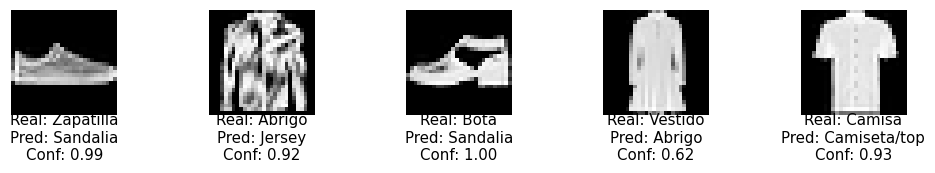

In [34]:
print('5 Casos Erróneos en el conjunto de Test:')

# Obtener los índices de los casos erróneos
error_indices = (
    all_predictions != all_targets
).nonzero(as_tuple=True)[0][:5]

figure = plt.figure(figsize=(10, 2))
plt.rc('font', size=9)

for i, idx in enumerate(error_indices):
    figure.add_subplot(1, 5, i + 1)

    img, _ = dataset_test[idx.item()] # Obtener la imagen del dataset original

    real_label = all_targets[idx].item()
    predicted_label = all_predictions[idx].item()
    confidence = all_confidences[idx].item()

    plt.imshow(img.squeeze(), cmap='Greys_r')
    plt.axis('off')
    plt.title(f"Real: {desc[real_label]}\nPred: {desc[predicted_label]}\nConf: {confidence:.2f}", y=-0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 6.5 · Demo de inferencia

El siguiente bloque de código integra la lógica para verificar y cargar el modelo, solicitar la carga de una imagen, preprocesarla, realizar la inferencia y mostrar los resultados, incluyendo una visualización de la imagen original y la procesada.

El flujo es lineal:

Modelo disponible
↓
Selector de imagen
↓
Inferencia
↓
Resultados

In [35]:
from torchvision import datasets
from google.colab import files
import os
import zipfile

# Dataset original de prueba FashionMNIST
demo_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True
)

class_names = [
    "camiseta_top",
    "pantalon",
    "jersey",
    "vestido",
    "abrigo",
    "sandalia",
    "camisa",
    "zapatilla",
    "bolso",
    "botin"
]

os.makedirs("imagenes_demo_28x28", exist_ok=True)

saved_classes = set()

for i in range(len(demo_dataset)):

    image, label = demo_dataset[i]

    if label not in saved_classes:

        filename = (
            f"imagenes_demo_28x28/"
            f"{label}_{class_names[label]}_28x28.png"
        )

        image.save(filename)

        saved_classes.add(label)

    if len(saved_classes) == 10:
        break

zip_name = "FashionMNIST_10_imagenes_28x28.zip"

with zipfile.ZipFile(zip_name, "w") as zipf:

    for filename in sorted(
        os.listdir("imagenes_demo_28x28")
    ):

        full_path = os.path.join(
            "imagenes_demo_28x28",
            filename
        )

        zipf.write(
            full_path,
            arcname=filename
        )

print("ZIP creado:", zip_name)

files.download(zip_name)

ZIP creado: FashionMNIST_10_imagenes_28x28.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =========================================================
# DEMO FINAL · FashionMNIST MLP
# =========================================================

import torch
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import io
from torchvision import transforms
import os

# ---------------------------------------------------------
# 1. DIAGNÓSTICO
# ---------------------------------------------------------

required = [
    "MLP",
    "input_size",
    "hidden_sizes",
    "output_size",
    "device",
    "desc"
]

missing = [x for x in required if x not in globals()]

if missing:
    print("❌ Faltan variables necesarias:")
    for x in missing:
        print(" -", x)

    print("\nEjecute primero las celdas de definición del modelo.")

else:

    # -----------------------------------------------------
    # 2. RECUPERAR MODELO
    # -----------------------------------------------------

    model_ready = False

    if "best_model_state" in globals():

        model = MLP(
            input_size,
            hidden_sizes,
            output_size
        ).to(device)

        model.load_state_dict(best_model_state)
        model.eval()

        model_ready = True

        print("✓ Modelo recuperado desde best_model_state.")

    elif "model" in globals():

        model = model.to(device)
        model.eval()

        model_ready = True

        print("✓ Modelo disponible en memoria.")

    else:

        print("❌ No existe model ni best_model_state.")
        print(
            "La sesión perdió el modelo entrenado. "
            "Debe ejecutar nuevamente la celda de entrenamiento "
            "o cargar un checkpoint guardado."
        )

    # -----------------------------------------------------
    # 3. CARGA DE IMAGEN
    # -----------------------------------------------------

    if model_ready:
        image_data = None
        image_filename = None

        try:
            from google.colab import files
            print("\nSeleccione UNA imagen PNG, JPG o JPEG (usando `google.colab.files.upload()`):")
            uploaded = files.upload()

            if len(uploaded) == 0:
                print("❌ No se seleccionó ninguna imagen.")
            else:
                image_filename = next(iter(uploaded))
                image_data = uploaded[image_filename]
                print(f"✓ Imagen '{image_filename}' cargada.")

        except ImportError:
            print("\nEl módulo 'google.colab.files' no está disponible. Por favor, suba una imagen manualmente al entorno de Colab y proporcione su ruta.")
            # Si google.colab no está disponible, pedimos al usuario que introduzca la ruta
            # Esto permite que la demo siga funcionando en entornos que no son Colab o si hay problemas con files.upload()
            manual_image_path = input("Introduzca la ruta de la imagen local (por ejemplo, 'mi_imagen.png'): ")
            if os.path.exists(manual_image_path):
                with open(manual_image_path, 'rb') as f:
                    image_data = f.read()
                image_filename = os.path.basename(manual_image_path)
                print(f"✓ Imagen '{image_filename}' cargada manualmente.")
            else:
                print(f"❌ No se encontró la imagen en la ruta: {manual_image_path}")
                image_data = None # Asegurar que no se intente procesar datos inexistentes

        if image_data:
            image = Image.open(
                io.BytesIO(image_data)
            ).convert("L")

            # -------------------------------------------------
            # 4. ADAPTACIÓN A FASHIONMNIST
            # -------------------------------------------------

            # Si el fondo es blanco, invertir automáticamente
            corners = [
                image.getpixel((0, 0)),
                image.getpixel((image.width-1, 0)),
                image.getpixel((0, image.height-1)),
                image.getpixel((image.width-1, image.height-1))
            ]

            if sum(corners) / 4 > 127:
                image = ImageOps.invert(image)

            image_28 = image.resize((28, 28))

            tensor = transforms.ToTensor()(image_28)

            tensor_normalized = (
                tensor - 0.2860
            ) / 0.3530

            input_tensor = (
                tensor_normalized
                .unsqueeze(0)
                .to(device)
            )

            # -------------------------------------------------
            # 5. INFERENCIA
            # -------------------------------------------------

            model.eval()

            with torch.no_grad():

                output = model(input_tensor)

                top_probs, top_indices = torch.topk(
                    output,
                    k=2,
                    dim=1
                )

            top1_idx = top_indices[0, 0].item()
            top2_idx = top_indices[0, 1].item()

            top1_prob = torch.nn.functional.softmax(top_probs, dim=1)[0, 0].item() * 100
            top2_prob = torch.nn.functional.softmax(top_probs, dim=1)[0, 1].item() * 100

            # -------------------------------------------------
            # 6. SMART REVIEW
            # -------------------------------------------------

            if top1_prob >= 80:
                review = "Alta confianza"
            elif top1_prob >= 60:
                review = "Confianza media"
            else:
                review = "Baja confianza · revisar"

            # -------------------------------------------------
            # 7. RESULTADOS
            # -------------------------------------------------

            print("\n------------------------------")
            print("RESULTADO")
            print("------------------------------")

            print(
                f"Top-1: {desc[top1_idx]} "
                f"({top1_prob:.2f}%)"
            )

            print(
                f"Top-2: {desc[top2_idx]} "
                f"({top2_prob:.2f}%)"
            )

            print("Smart Review:", review)

            # -------------------------------------------------
            # 8. VISUALIZACIÓN
            # -------------------------------------------------

            plt.figure(figsize=(4, 4))

            plt.imshow(
                image_28,
                cmap="gray"
            )

            plt.title(
                f"Predicción: {desc[top1_idx]}\n"
                f"Confianza: {top1_prob:.2f}%"
            )

            plt.axis("off")
            plt.tight_layout()
            plt.show()

✓ Modelo recuperado desde best_model_state.

Seleccione UNA imagen PNG, JPG o JPEG:


<div style="background-color: #FFF7EB; border: 1px solid #FFD699; border-radius: 8px; padding: 15px; margin-top: 20px; text-align: center;">
    <h4 style="color: #E67A00; margin-top: 0; margin-bottom: 10px;">Demo experimental · Cambio de dominio</h4>
    <p style="font-size: 0.95em; color: #333; margin: 0;">
        El modelo fue entrenado con FashionMNIST, cuyas imágenes son de 28×28 píxeles, en escala de grises y con características visuales estandarizadas.
        Una fotografía externa puede diferir significativamente de esa distribución. Esta demo demuestra el pipeline de inferencia, pero no implica que la precisión obtenida sobre FashionMNIST sea directamente transferible a fotografías del mundo real.
    </p>
</div>

Esta diferencia entre los datos utilizados para entrenar y los datos encontrados posteriormente se conoce como **cambio de dominio o *domain shift***.

<p style="font-size: 1.0em; color: {APPLE_GRAY}; margin-bottom: 5px; margin-top: 20px;">APLICABILIDAD</p>

La demo ilustra el paso desde un modelo evaluado en un notebook hacia
un flujo de inferencia interactivo. En un sistema real sería necesario
validar posteriormente el modelo con imágenes representativas del entorno
de uso, versionar el pipeline de preprocesamiento y establecer criterios
operativos de revisión.

MODELO ACADÉMICO
↓
Modelo validado
↓
Demo de inferencia
↓
Validación con datos reales
↓
Interfaz / API
↓
Monitoreo
↓
Producción futura

## 07 · Conclusión

### 7.1 · Aplicabilidad de lo aprendido

El principal aprendizaje de esta actividad no se limita a clasificar prendas de FashionMNIST. Comprender el ciclo completo de construcción y evaluación de un modelo de clasificación es la clave. La separación entre entrenamiento, validación y test permitió utilizar cada conjunto con una finalidad diferente: el conjunto de **entrenamiento** se usó para que el modelo aprendiera los parámetros; el conjunto de **validación** sirvió para evaluar la capacidad de generalización durante el entrenamiento y seleccionar el mejor estado del modelo; y el conjunto de **test** se utilizó, finalmente, para realizar una evaluación independiente y no sesgada sobre datos no vistos ni utilizados para dicha selección o ajuste. Esta metodología, que incluye: Datos → Preprocesamiento → Entrenamiento → Validación → Selección del mejor modelo → Test → Interpretación → Decisión, puede transferirse conceptualmente a diversos problemas de clasificación con categorías predefinidas, como la clasificación de productos, la inspección visual para control de calidad, la identificación de defectos, la clasificación documental, el reconocimiento de patrones o la creación de sistemas de priorización para revisión humana. Este modelo, si bien no es directamente utilizable en estas aplicaciones sin una validación exhaustiva, sienta las bases metodológicas para su desarrollo.

### 7.2 · Del modelo a producción

Transformar un modelo académico en un sistema utilizable en producción requiere una serie de pasos controlados que van más allá del entrenamiento.

MODELO VALIDADO
↓
Guardar mejor modelo
↓
Pipeline de preprocesamiento
↓
Función de inferencia
↓
Smart Review
↓
Interfaz / API
↓
Validación con datos reales
↓
Monitoreo
↓
Actualización futura

---

**1. Guardar el mejor modelo**

En una aplicación real, se utilizaría el mejor estado del modelo seleccionado durante la validación (`best_model_state`). Este estado se podría guardar para su posterior carga, por ejemplo, conceptualmente con `torch.save(best_model_state, "fashion_mnist_mlp.pth")`. Es crucial almacenar junto al modelo su arquitectura, los nombres de las clases y los parámetros de normalización usados.

**2. Pipeline de preprocesamiento**

Cualquier nueva imagen debe ser transformada exactamente de la misma manera que los datos de entrenamiento. Esto implica el siguiente flujo: Imagen → Escala de grises → 28 × 28 píxeles → Tensor → Normalización (media = 0.2860, desviación = 0.3530) → 784 valores → MLP. El preprocesamiento es una parte integral del sistema en producción y debe ser idéntico al del entrenamiento.

**3. Función de inferencia**

La aplicación requeriría una función capaz de recibir una imagen nueva y devolver la categoría predicha (Top-1), su confianza Softmax, la segunda categoría más probable (Top-2) con su confianza, y un nivel Smart Review. Por ejemplo, podría retornar:

PREDICCIÓN
Clase: Camisa
Confianza: 93.4 %
Segunda opción: Camiseta/top · 4.8 %
Estado: Alta confianza

*Nota: Las cifras son ilustrativas.*

**4. Smart Review como regla de decisión**

El concepto de Smart Review, desarrollado en este notebook, sirve como una regla de decisión operativa:

*   **>= 80 % (ALTA CONFIANZA):** Candidata a tratamiento automático.
*   **60 % a <80 % (CONFIANZA MEDIA):** Resultado que merece mayor atención.
*   **<60 % (REVISAR):** Candidato a revisión humana.

Estos umbrales son demostrativos y deberían validarse con datos reales, criterios operativos y los niveles de riesgo aceptables para la aplicación específica.

**5. Interfaz o servicio de predicción**

El modelo podría integrarse en una interfaz web, una aplicación, un servicio API o un sistema interno. Conceptualizando el flujo: Usuario/Sistema → Carga imagen → Preprocesamiento → MLP → Predicción → Smart Review → Resultado. Herramientas como Streamlit o Gradio pueden usarse para prototipos, mientras que APIs robustas serían necesarias para entornos de producción.

**6. Validación con datos reales**

Es fundamental comprender que el modelo entrenado con FashionMNIST (imágenes 28×28, escala de grises, fondo y formato estandarizados) **no está diseñado** para clasificar directamente fotografías reales tomadas con un teléfono móvil. Antes de la producción, sería indispensable: disponer de imágenes representativas del entorno real, definir las clases, verificar la calidad y balance del dataset, evaluar el modelo con esos datos y, si fuera necesario, adaptarlo o reentrenarlo.

**7. Monitoreo en producción**

Un modelo en producción requiere monitoreo continuo. Esto incluye el volumen de predicciones, la distribución de clases y confianza, el porcentaje de casos enviados a revisión, tiempos de respuesta, errores técnicos, la precisión cuando se dispone de etiquetas reales posteriores, y cambios en las características de los datos (`data drift`), que se refieren a la variación de los datos de entrada respecto a los usados en entrenamiento.

**8. Ciclo de mejora**

Un sistema real contempla un ciclo de mejora: Producción → Nuevos datos → Monitoreo → Casos difíciles → Revisión → Dataset actualizado → Nueva validación → Futura versión del modelo. Este ciclo correspondería a una fase posterior del proyecto.

---

**PROTOTIPO ACTUAL**
✓ MLP entrenada
✓ Validación independiente
✓ Test independiente
✓ Análisis de errores
✓ Smart Review

**PARA PRODUCCIÓN**
○ Datos representativos del entorno real
○ Pipeline de entrada controlado
○ Persistencia/versionado del modelo
○ Interfaz o API
○ Validación operativa
○ Monitoreo
○ Gobierno y mantenimiento del modelo

---

Pasar un modelo a producción no significa únicamente guardar sus pesos.
También requiere controlar las entradas, reproducir el preprocesamiento,
integrar la inferencia en un sistema, definir reglas de decisión y
monitorear continuamente su desempeño.

Smart Review representa una primera aproximación a una regla de decisión posterior a la clasificación (Modelo → Predicción → Confianza → Decisión), ilustrando cómo combinar automatización con revisión humana en un sistema.

### 7.3 · Conclusión final

Este ejercicio ha demostrado el ciclo completo de desarrollo de un modelo de clasificación con una MLP de arquitectura 784 → 512 → 256 → 128 → 10. La rigurosa separación en conjuntos de Train, Validation y Test fue esencial para seleccionar el mejor estado del modelo, que superó el 89 % de precisión en validación. El análisis de errores, la matriz de confusión y la precisión por clase permitieron identificar las categorías más desafiantes. Además, Smart Review proporcionó una interpretación práctica de las predicciones, relacionando el nivel de confianza del modelo con posibles criterios de revisión humana. Este proceso subraya que, aunque el modelo de FashionMNIST no esté listo para producción, la metodología es aplicable. El principal aprendizaje no fue únicamente entrenar una red neuronal, sino comprender el ciclo que conecta los datos, el modelo, la validación, la interpretación y una posible aplicación futura.